# Import libraries

In [1]:
# Changes to all modules will automatically be applied when any cell runs. 
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np

import optuna

from pathlib import Path
import sys

from typing import Type
from sklearn.base import BaseEstimator
sys.path.append(
    str(Path('..', 'utils_functionality', 'split_utils'))
)
from split_tools import get_train_test

sys.path.append(
    str(Path('..', 'utils_functionality', 'models'))
)

from modelling4_utils import (
    BetaVAEncoder,
    MLPipeline,
    OptunaOptimizer,
    deep_update_dim_transformer_params,
    RANDOM_STATE,
)

seed = RANDOM_STATE

from catboost import CatBoostClassifier
from statsmodels.api import Logit

from sklearn.decomposition import PCA

from sklearn.metrics import (
    make_scorer,
    f1_score,
    mean_squared_error
)

import optuna
from functools import partial



## Settings

In [3]:
model_postfix = 'vae'

scoring_metrics={
    'mse': mean_squared_error,
}
step_scoring_average = "mean"
n_trials = 1000 # make 300

features_to_drop=(
    'sign_sedimentation_Re',
    'sign_sedimentation_Stk',
    'sign_particle_droplet_diameter_ratio',
)

save_model_and_metrics = False
metrics_file = "metrics_modelling4_7-dim_reduction.xlsx"

## Optimization function

In [4]:
def optimize_vae_optuna(
    dim_transformer:Type[BaseEstimator]=BetaVAEncoder,
    dim_transformer_params:dict=None,
    dummy_target:str='splashing', # placeholder
    dummy_estimator:Type[BaseEstimator]=CatBoostClassifier,  # placeholder
    objective:callable=None,
    direction:str="minimize",
    n_trials:int=n_trials,
    features_to_drop:tuple=features_to_drop,
    step_scoring_average:str=step_scoring_average,
    scoring_metrics:dict=scoring_metrics,
    verbose:bool=True,
    opt_cv_folds:int=5,
    seed:int=seed,
):
    dim_transformer_params = dim_transformer_params or {}
    
    ml_pipe = MLPipeline(
        target=dummy_target,
        estimator=dummy_estimator,
        dim_transformer=dim_transformer,
        dim_transformer_params=dim_transformer_params,
        features_to_drop=features_to_drop,
        cv_folds=opt_cv_folds,
        verbose=verbose,
        step_scoring_average=step_scoring_average,
        scoring_metrics=scoring_metrics,
    )
    
    opt = OptunaOptimizer(
        objective=partial(
            objective,
            ml_pipe=ml_pipe,
        ),
        study_name='VAE_study',
        direction=direction,
        seed=seed,
    )
    
    opt.optimize(n_trials=n_trials)
    
    best_params = opt.study.best_params
    
    print('raw best_params')
    display(best_params)


def VAE_objective(
    trial:optuna.trial.Trial,
    ml_pipe:MLPipeline,
):
    # VAE params
    hidden_dim = 2**trial.suggest_int('log2_hidden_dim', 2, 8)
    normalization = trial.suggest_categorical('normalization', ['batch', 'layer', False])
    activation = trial.suggest_categorical('activation', ['ReLU', 'LeakyReLU', False])
    
    if activation == 'LeakyReLU':
        negative_slope = trial.suggest_float('negative_slope', 0.01, .3, log=True)
    else:
        negative_slope = None
    
    # BetaVAEncoder params
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)
    beta_warmup_steps = trial.suggest_int('beta_warmup_steps', 100, 1000)
    beta_start = trial.suggest_float('beta_start', 0.0, 0.5)
    beta_end = trial.suggest_float('beta_end', 1.0, 10.0)
    
    suggested_transformer_params = {
        'VAE_params': {
            'hidden_dim': hidden_dim,
            'normalization': normalization,
            'activation': activation,
            'negative_slope': negative_slope,
        },
        'learning_rate': learning_rate,
        'beta_warmup_steps': beta_warmup_steps,
        'beta_start': beta_start,
        'beta_end': beta_end,
    }
    
    dim_transformer_params = deep_update_dim_transformer_params(
        ml_pipe=ml_pipe,
        suggested_params=suggested_transformer_params,
    )
    
    score = ml_pipe.step_transformer(
        dim_transformer_params=dim_transformer_params,
    )
    
    score_val = score[0]
    # score_train = score[1]
    return score_val


In [5]:
optimize_vae_optuna(
    dim_transformer_params={
        'VAE_params': {
            'latent_dim': 5,
        },
        'verbose': False,
        'early_stopping': True,
        'early_stopping_patience': 30,
        'max_epochs': 300,
    },
    objective=VAE_objective,
)

Load dataset from: ../data/df_dimless.xlsx
Keep "splashing" from {'no_fragmentation', 'splashing'}
Load split indexes from: ../data/df_ml_split_splashing.xlsx
std_features


('sedimentation_Re',
 'sedimentation_Stk',
 'particle_liquid_density_ratio',
 'particle_droplet_diameter_ratio',
 'relative_roughness',
 'Re',
 'We',
 'K')

ColumnTransformer(transformers=[('minmax', MinMaxScaler(),
                                 ('inclination', 'init_volume_fraction',
                                  'volume_fraction')),
                                ('std', StandardScaler(),
                                 ('sedimentation_Re', 'sedimentation_Stk',
                                  'particle_liquid_density_ratio',
                                  'particle_droplet_diameter_ratio',
                                  'relative_roughness', 'Re', 'We', 'K')),
                                ('passthrough', 'passthrough',
                                 ('wettability',))])

[I 2025-05-02 13:41:44,682] A new study created in memory with name: VAE_study
[I 2025-05-02 13:41:45,992] Trial 0 finished with value: 0.28220390260717537 and parameters: {'log2_hidden_dim': 4, 'normalization': 'batch', 'activation': 'ReLU', 'learning_rate': 0.029154431891537533, 'beta_warmup_steps': 641, 'beta_start': 0.35403628889802274, 'beta_end': 1.185260448662222}. Best is trial 0 with value: 0.28220390260717537.
[I 2025-05-02 13:41:46,943] Trial 1 finished with value: 0.4055141708444112 and parameters: {'log2_hidden_dim': 8, 'normalization': 'batch', 'activation': False, 'learning_rate': 0.0005342937261279777, 'beta_warmup_steps': 362, 'beta_start': 0.30592644736118974, 'beta_end': 2.2554447458683766}. Best is trial 0 with value: 0.28220390260717537.
[I 2025-05-02 13:41:47,803] Trial 2 finished with value: 0.8228577549480847 and parameters: {'log2_hidden_dim': 4, 'normalization': False, 'activation': False, 'learning_rate': 1.5339162591163613e-05, 'beta_warmup_steps': 647, 'bet

KeyboardInterrupt: 

In [ ]:

# To simplify data extraction, initialize ml_pipe
target = 'splashing'

ml_pipe = MLPipeline(
    target=target,
    estimator=CatBoostClassifier,
    estimator_params={'verbose': False,},
    # dim_transformer=PCA,
    # dim_transformer_params={'n_components': 6},
    dim_transformer=BetaVAEncoder,
    dim_transformer_params={
        'VAE_params': {
            'latent_dim': 5,
            'hidden_dim': 256,
        },
        'verbose': False,
        'learning_rate': 5e-2,
        'early_stopping': True,
        'early_stopping_patience': 30,
        # scheduler_class=None,
        'beta_warmup_steps': 200,
        'beta_start': 0.0,
        'beta_end': 1.,
        'max_epochs': 1000,
    },
    features_to_drop=(
        'sign_sedimentation_Re',
        'sign_sedimentation_Stk',
        'sign_particle_droplet_diameter_ratio',
    ),
    cv_folds=7,
    model_postfix=model_postfix,
    verbose=True,
    scoring_metrics=scoring_metrics,
)

# X_train = ml_pipe.train.drop(columns=[target])
# X_test = ml_pipe.test.drop(columns=[target])
# display(X_train.info())
# display(X_test.info())

# ml_pipe.run(
#     save_model_and_metrics=False,
#     cv_verbose=False,
# )

Load dataset from: ../data/df_dimless.xlsx
Keep "splashing" from {'no_fragmentation', 'splashing'}
Load split indexes from: ../data/df_ml_split_splashing.xlsx
std_features


('sedimentation_Re',
 'sedimentation_Stk',
 'particle_liquid_density_ratio',
 'particle_droplet_diameter_ratio',
 'relative_roughness',
 'Re',
 'We',
 'K')

ColumnTransformer(transformers=[('minmax', MinMaxScaler(),
                                 ('inclination', 'init_volume_fraction',
                                  'volume_fraction')),
                                ('std', StandardScaler(),
                                 ('sedimentation_Re', 'sedimentation_Stk',
                                  'particle_liquid_density_ratio',
                                  'particle_droplet_diameter_ratio',
                                  'relative_roughness', 'Re', 'We', 'K')),
                                ('passthrough', 'passthrough',
                                 ('wettability',))])

In [11]:
ml_pipe.step_transformer()

# device_name = 'cpu' at final stage, when best model is selected

(0.3616843374222957, 0.35792170137263796)

Оптимизируем параметры VAE encoder, прибегнув к кросс-валидационной оценке MSE при реконструкции исходных признаков

,inclination,init_volume_fraction,volume_fraction,sedimentation_Re,sedimentation_Stk,particle_liquid_density_ratio,particle_droplet_diameter_ratio,relative_roughness,Re,We,K,wettability
0,1.000000,1.000000,0.282373,0.430793,0.319496,-0.532898,-0.486567,-0.990182,-0.661716,-1.521437,-1.505982,0.0
1,0.000000,0.666667,0.247794,-1.839632,-1.781609,0.034384,1.210831,0.942521,1.851042,-0.103229,1.298899,-1.0
2,0.000000,0.666667,0.247794,-1.839632,-1.781609,0.034384,-0.451370,0.976371,2.621513,1.286257,2.751097,-1.0
3,0.000000,0.666667,0.247794,-1.839632,-1.781609,0.034384,-0.633073,0.918092,0.697760,-1.314894,-0.479905,-1.0
4,0.000000,0.666667,0.403454,0.609457,0.650018,3.248981,-0.673893,0.905000,-0.559590,0.625716,-0.060832,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
292,0.000000,1.000000,0.298772,0.430793,0.327838,-0.532898,-0.394308,-0.526914,-0.646090,-1.276325,-1.273413,1.0
293,0.000000,0.666667,0.580877,0.780758,1.082729,0.097415,2.437398,1.007860,-0.647863,-1.291232,-1.288883,-1.0
294,0.000000,0.000000,0.107180,0.624949,0.691758,3.248981,-0.444570,0.978552,-0.582752,0.225713,-0.300807,-1.0
295,0.000000,0.000000,0.054376,-1.839632,-1.781609,0.034384,1.072988,-1.056954,2.121589,0.089539,1.569714,0.0


VAE_params: {'latent_dim': 5, 'hidden_dim': 256, 'input_dim': 12, 'verbose': True}
Encoder: Sequential(
  (0): Linear(in_features=12, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): LeakyReLU(negative_slope=0.1, inplace=True)
)
Latent space:
	Mu: Linear(in_features=256, out_features=5, bias=True)
	log_sigma2: Linear(in_features=256, out_features=5, bias=True)
Decoder: Sequential(
  (0): Linear(in_features=5, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): LeakyReLU(negative_slope=0.1, inplace=True)
  (3): Linear(in_features=256, out_features=12, bias=True)
)


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping at epoch 45.


,inclination,init_volume_fraction,volume_fraction,sedimentation_Re,sedimentation_Stk,particle_liquid_density_ratio,particle_droplet_diameter_ratio,relative_roughness,Re,We,K,wettability
0,0.289378,0.658617,0.242735,0.426806,0.359502,-0.309063,-0.061977,-0.098419,-0.458809,-0.279695,-0.474826,0.182995
1,0.140253,0.564720,0.188509,-1.265310,-1.200573,-0.052236,-0.200799,0.144475,1.238948,-0.048680,0.866151,0.001385
2,0.070515,0.532285,0.200028,-1.630331,-1.580479,0.027964,-0.193033,0.290584,1.829722,0.175761,1.456007,-0.024193
3,0.233207,0.598097,0.191845,-0.783270,-0.783285,-0.158326,-0.328039,-0.027540,0.511351,-0.301134,0.191021,0.060375
4,0.074957,0.442560,0.192855,0.582660,0.602485,1.204631,-0.272600,0.138633,-0.507284,0.467242,-0.065127,0.111261
...,...,...,...,...,...,...,...,...,...,...,...,...
292,0.256146,0.637363,0.232175,0.446299,0.376655,-0.311384,-0.084255,-0.036697,-0.448366,-0.169309,-0.399581,0.160958
293,0.273413,0.640568,0.264955,0.550452,0.548757,-0.262756,0.368465,-0.029140,-0.526351,-0.265377,-0.511154,0.166412
294,0.071632,0.425729,0.196394,0.607754,0.628521,1.376631,-0.251645,0.156243,-0.537474,0.456016,-0.090706,0.099417
295,0.145145,0.524225,0.195689,-1.360564,-1.324217,-0.042840,-0.170462,-0.047421,1.307969,-0.068873,0.894909,0.106469


MSE: 0.39691998705580267


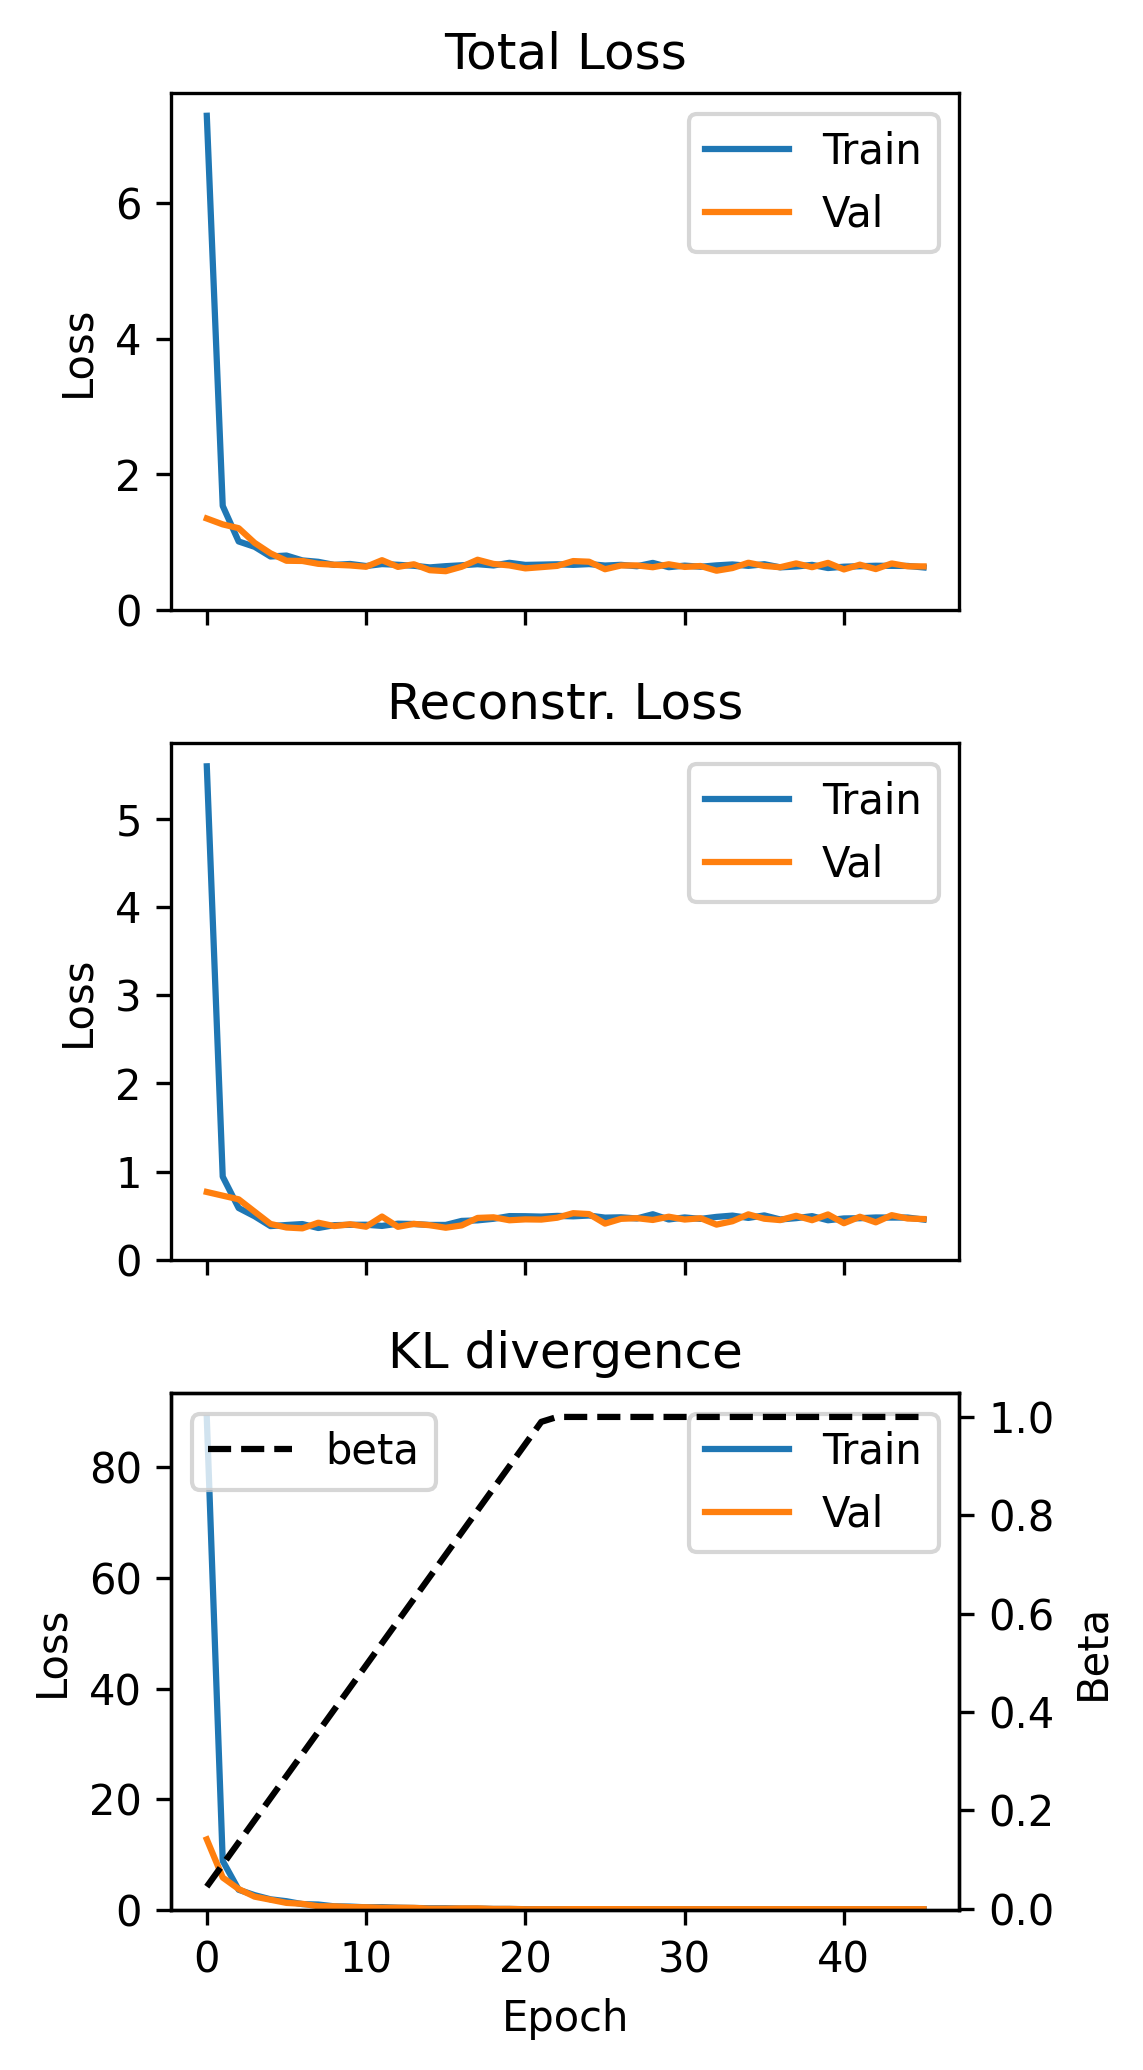

In [4]:
X_train = ml_pipe.train.drop(columns=[target])

preproc = ml_pipe.pipe[:-3]
X_train_preproc = preproc.fit_transform(X_train)
display(X_train_preproc)

Z_train = ml_pipe.pipe[-3].fit_transform(X_train_preproc)
X_train_preproc_reconstr = ml_pipe.pipe[-3].inverse_transform(Z_train)
X_train_preproc_reconstr = pd.DataFrame(
    X_train_preproc_reconstr,
    index=X_train_preproc.index,
    columns=X_train_preproc.columns,
)
display(X_train_preproc_reconstr)

MSE = mean_squared_error(
    X_train_preproc,
    X_train_preproc_reconstr
)

print(f'MSE: {MSE}')